In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv('/content/star_classification.csv')

df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [4]:
print(df.shape)

df.info()

df.describe()

(100000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(1

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [5]:
df.isnull().sum()

,0
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


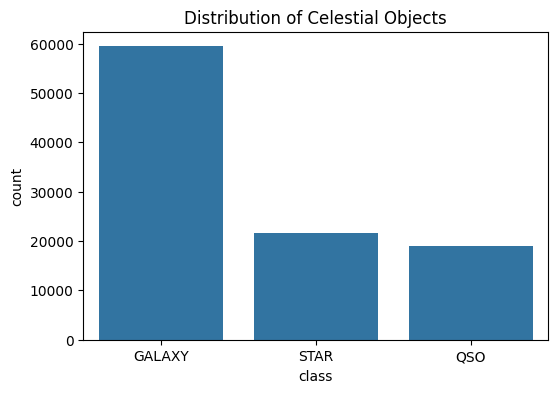

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='class',
    order=df['class'].value_counts().index
)

plt.title('Distribution of Celestial Objects')
plt.show()

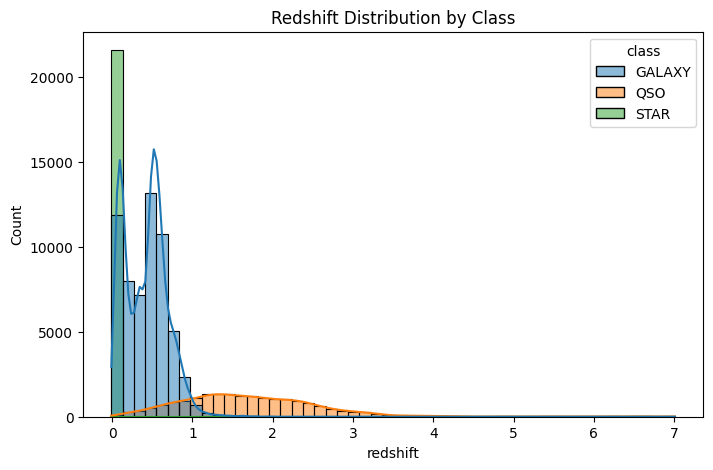

In [8]:
#redshift analysis

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='redshift',
    hue='class',
    bins=50,
    kde=True
)

plt.title('Redshift Distribution by Class')
plt.show()

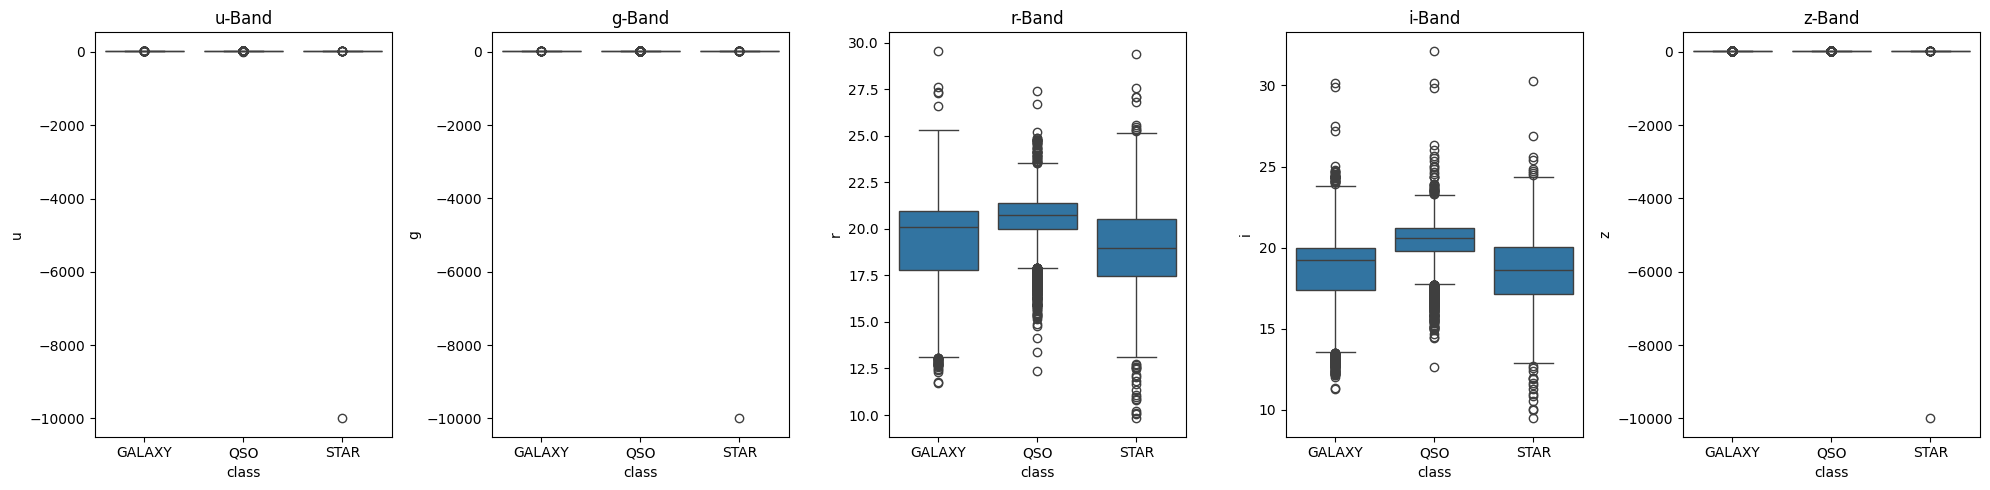

In [9]:
#photometric band boxplots
bands = ['u','g','r','i','z']

fig, axes = plt.subplots(1,5,figsize=(20,5))

for idx, band in enumerate(bands):

    sns.boxplot(
        data=df,
        x='class',
        y=band,
        ax=axes[idx]
    )

    axes[idx].set_title(f'{band}-Band')

plt.tight_layout()
plt.show()

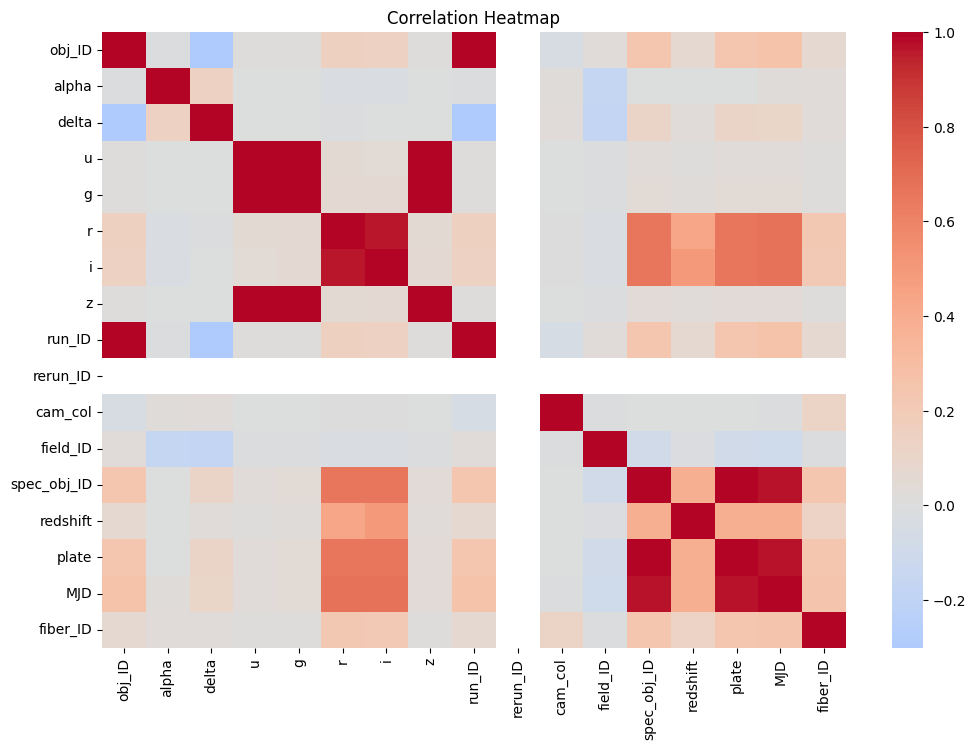

In [10]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

In [11]:
drop_cols = [
    'obj_ID',
    'run_ID',
    'rerun_ID',
    'cam_col',
    'field_ID',
    'spec_obj_ID'
]

df = df.drop(columns=drop_cols)

In [12]:
le = LabelEncoder()

df['class'] = le.fit_transform(df['class'])

df['class'].value_counts()

,count
class,
0,59445
2,21594
1,18961


In [13]:
X = df.drop('class', axis=1)

y = df['class']

In [14]:
X = df.drop('class', axis=1)

y = df['class']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [19]:
#train the models

models = {

    'Logistic Regression':
        LogisticRegression(max_iter=2000),

    'Decision Tree':
        DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ),

    'KNN':
        KNeighborsClassifier(
            n_neighbors=5
        ),

    'SVM':
        SVC(
            kernel='rbf'
        ),

    'XGBoost':
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='mlogloss'
        )
}

In [21]:
results = {}

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    pred = model.predict(
        X_test_scaled
    )

    acc = accuracy_score(
        y_test,
        pred
    )

    results[name] = acc

    print(f'\n{name}')
    print(f'Accuracy : {acc:.4f}')


Logistic Regression
Accuracy : 0.9548

Decision Tree
Accuracy : 0.9752

KNN
Accuracy : 0.9260

SVM
Accuracy : 0.9601

XGBoost
Accuracy : 0.9769


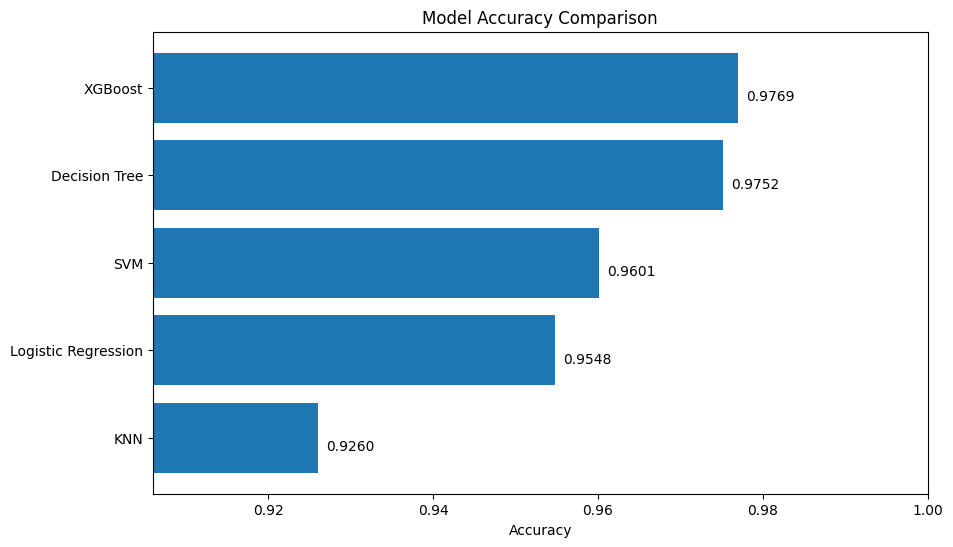

In [22]:
results_df = pd.DataFrame({
    'Model':results.keys(),
    'Accuracy':results.values()
})

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=True
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    results_df['Model'],
    results_df['Accuracy']
)

plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')

for bar in bars:
    plt.text(
        bar.get_width()+0.001,
        bar.get_y()+0.25,
        f'{bar.get_width():.4f}'
    )

plt.xlim(
    results_df['Accuracy'].min()-0.02,
    1.0
)

plt.show()

In [23]:
best_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

best_model.fit(
    X_train_scaled,
    y_train
)

y_pred = best_model.predict(
    X_test_scaled
)

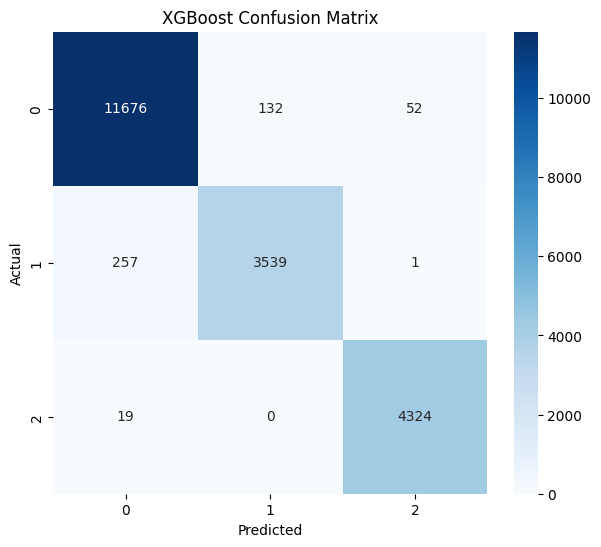

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('XGBoost Confusion Matrix')

plt.show()

In [25]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11860
         QSO       0.96      0.93      0.95      3797
        STAR       0.99      1.00      0.99      4343

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



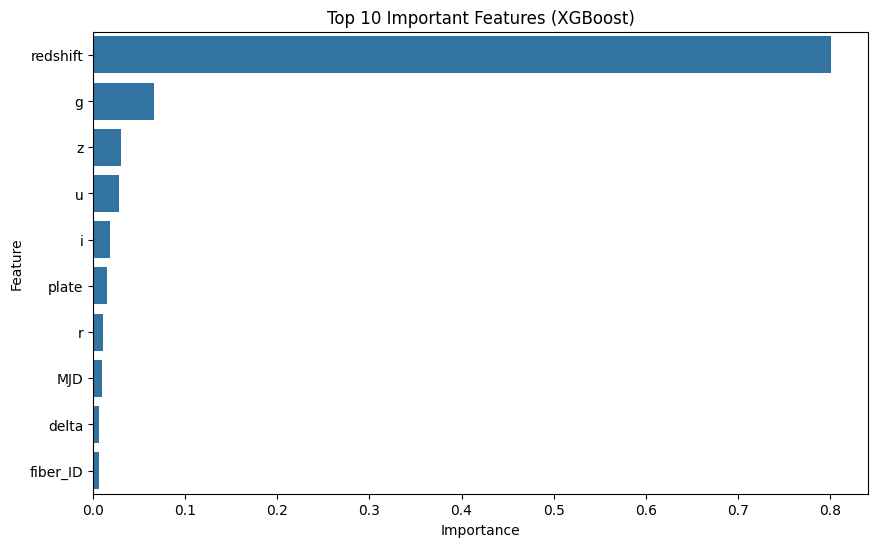

In [26]:
importance = pd.DataFrame({

    'Feature':X.columns,
    'Importance':best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Important Features (XGBoost)'
)

plt.show()